Plan a suivre :
1- download audio done

2- ajouter une bruit done

3-Analyser le signal audio bruité done

4-Concevoir et implémenter le filtre rif done ,

5-Tester et évaluer le filtre doneeee

In [ ]:
#library
import numpy as np
import librosa
import librosa.display
import scipy.signal as signal
import matplotlib.pyplot as plt
from scipy.io.wavfile import write
import soundfile as sf

 Tout d'abord , On cherche la gamme de fréquences (frequency range) du signal audio propre pour pouvoir choisir un filtre adapté qui supprimera uniquement le bruit sans dégrader le signal utile.


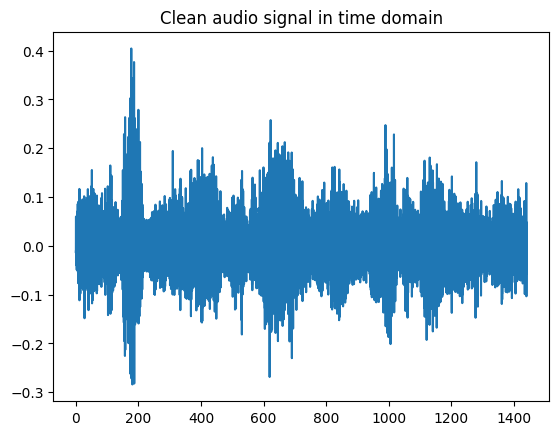

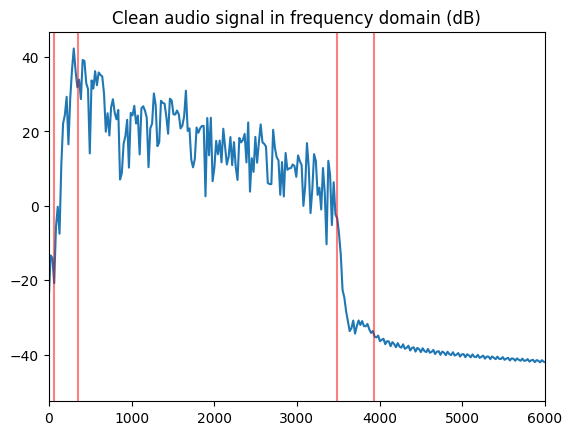

In [ ]:
clean_audio, sr = librosa.load('/content/clean_audio.wav')
t = librosa.frames_to_time(range(len(clean_audio)), sr=sr)#Crée une liste d’indices pour tous les échantillons audio.
plt.plot(t, clean_audio)
plt.title("Clean audio signal in time domain")
plt.show()
w, h = signal.freqz(clean_audio)
plt.plot(sr * w / (2 * np.pi), 20 * np.log10(np.abs(h)))
plt.title("Clean audio signal in frequency domain (dB)")
plt.xlim(0, 6000)
plt.axvline(x=60, color="red", alpha=0.5)
plt.axvline(x=350, color="red", alpha=0.5)
plt.axvline(x=3490, color="red", alpha=0.5)
plt.axvline(x=3930, color="red", alpha=0.5)

On observe que le signal audio commence à environ 350Hz et se termine à 3490Hz tout en ayant une largeur de transition de 300Hz et une atténuation de -39dB


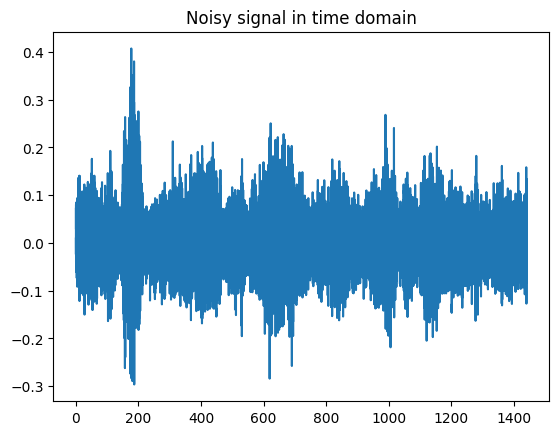

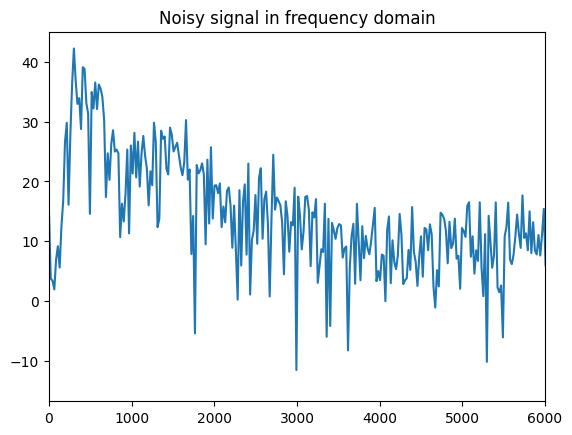

In [15]:
# Ajouter du bruit blanc
noise = np.random.normal(0, 0.015, clean_audio.shape)
noisy_signal = clean_audio + noise
# Sauvegarder le signal bruité
sf.write("noisy_audio.wav", noisy_signal, sr )
plt.plot(t, noisy_signal)
plt.title("Noisy signal in time domain")
plt.show()
w, h2 = signal.freqz(noisy_signal)
plt.plot(sr * w / (2 * np.pi), 20 * np.log10(np.abs(h2)))
plt.title("Noisy signal in frequency domain")
plt.xlim(0, 6000)
sf.write('noisy_audio.wav', noisy_signal, sr)

Nous allons maintenant essayer les filtres FIR (en utilisant la méthode de fenêtrage) sur le signal bruité et comparer les performances de chaque fenêtre au signal propre d'origine

SNR for Rectangulare: 12.86 dB


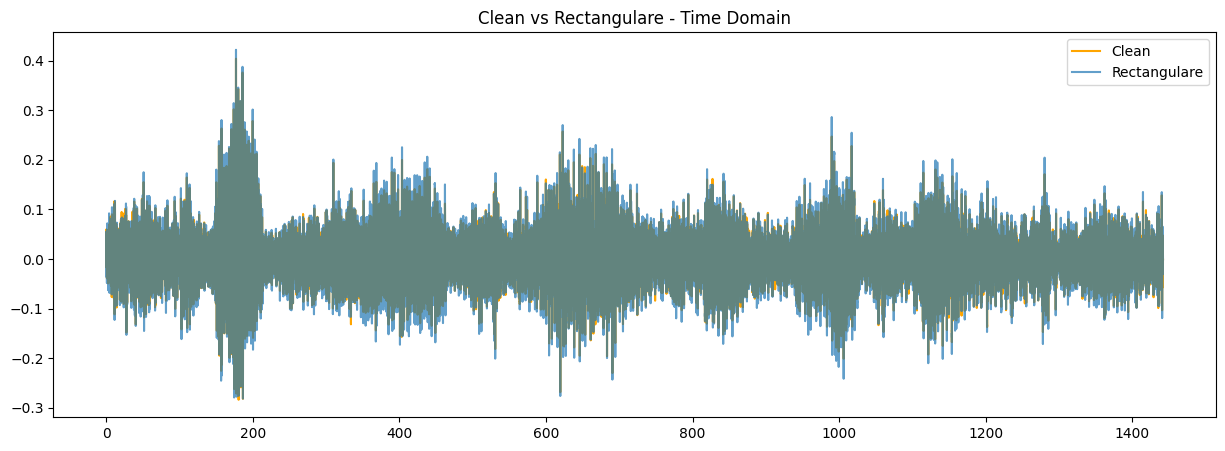

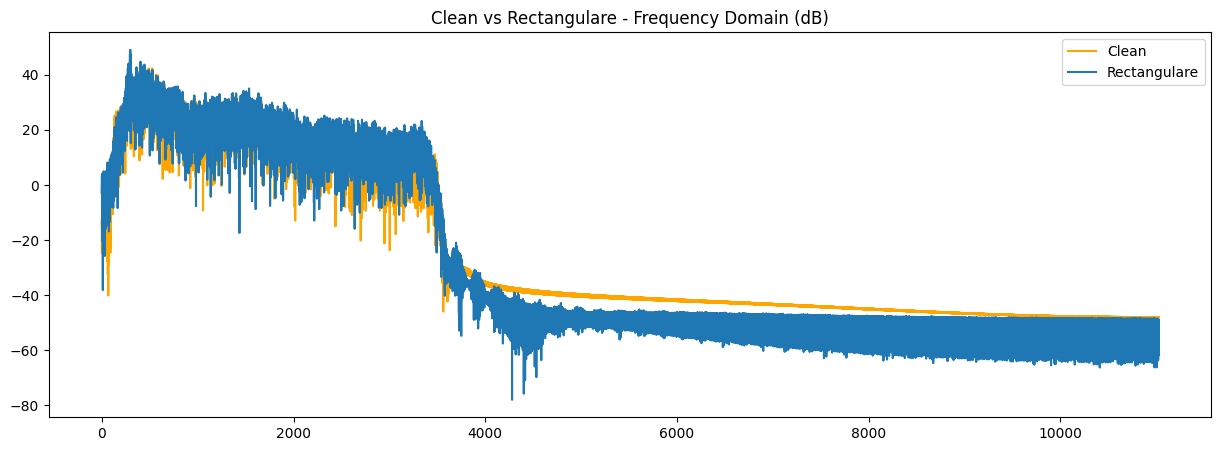

SNR for Triangulaire: 15.60 dB


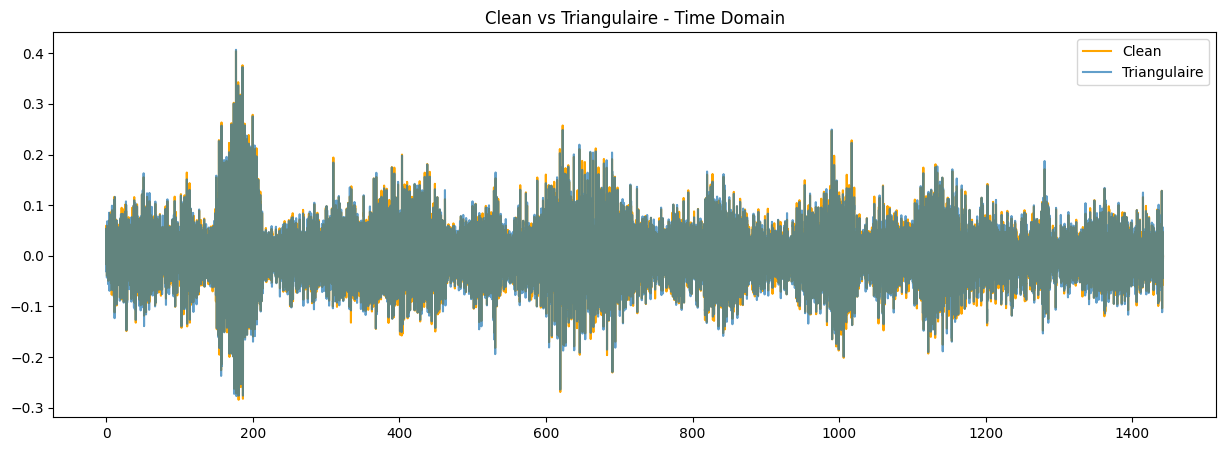

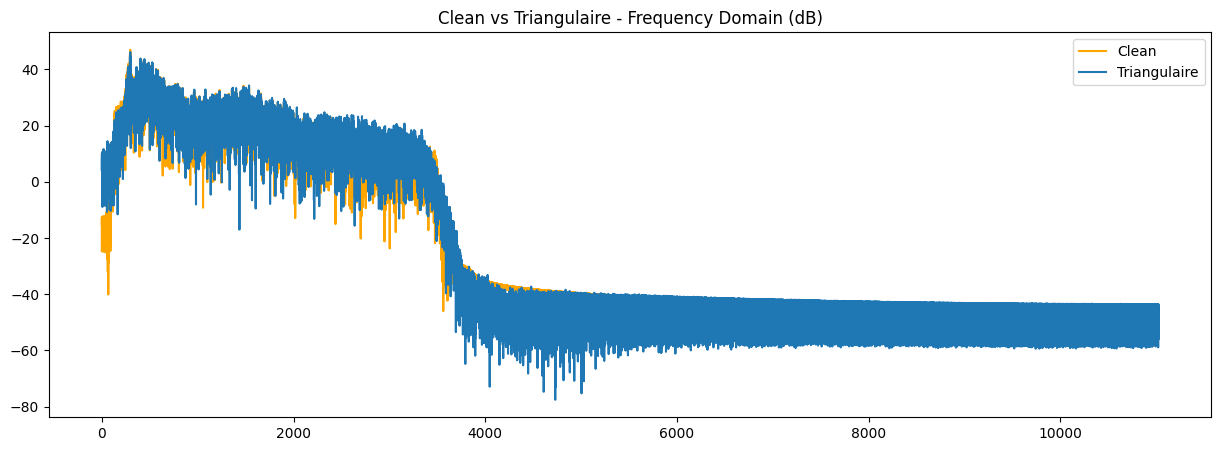

SNR for Parabolic: 14.62 dB


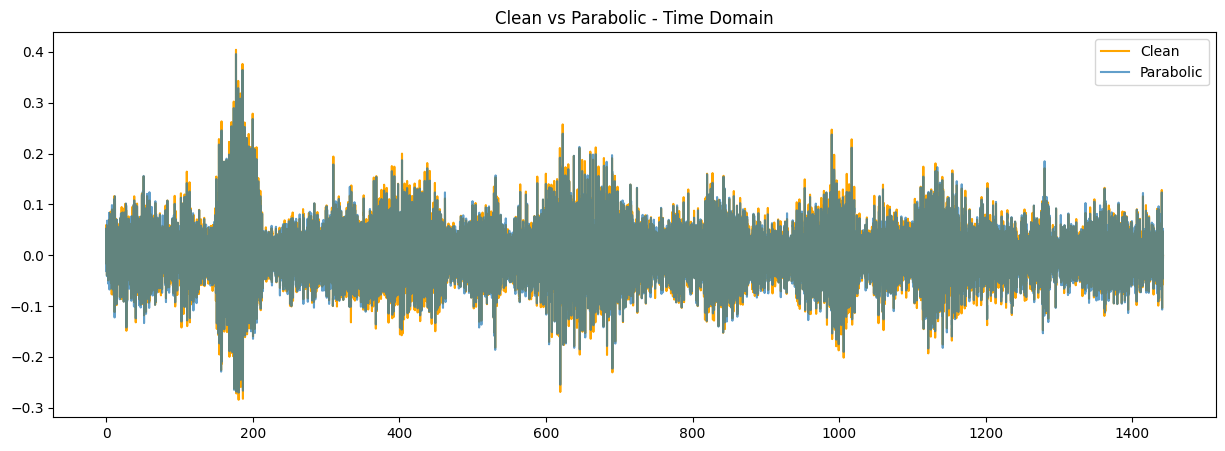

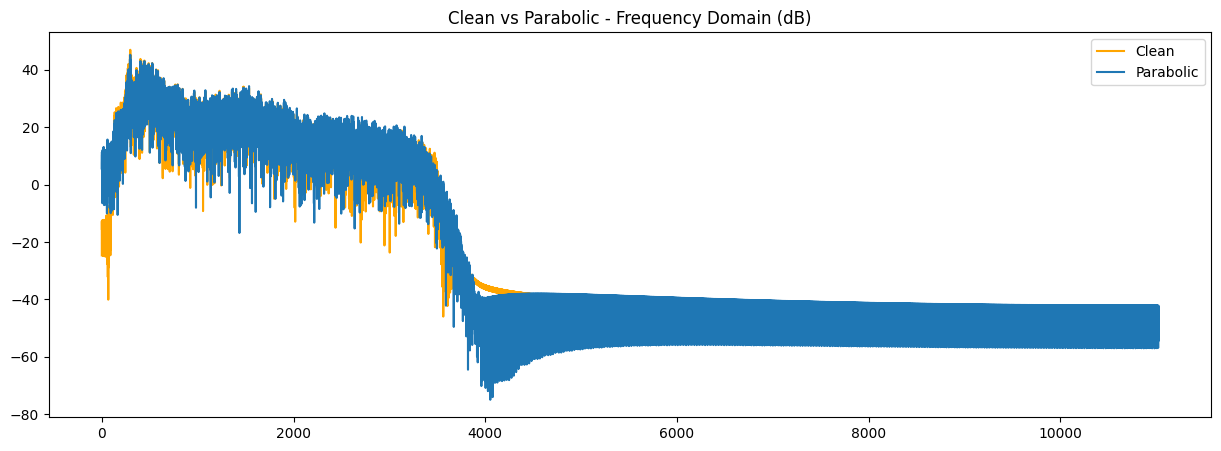

SNR for Polynomial: 14.51 dB


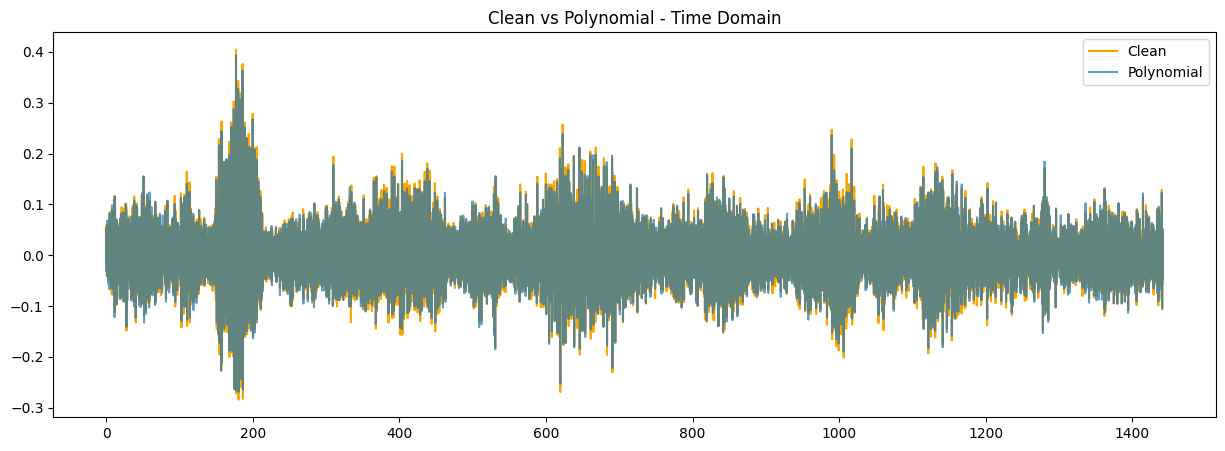

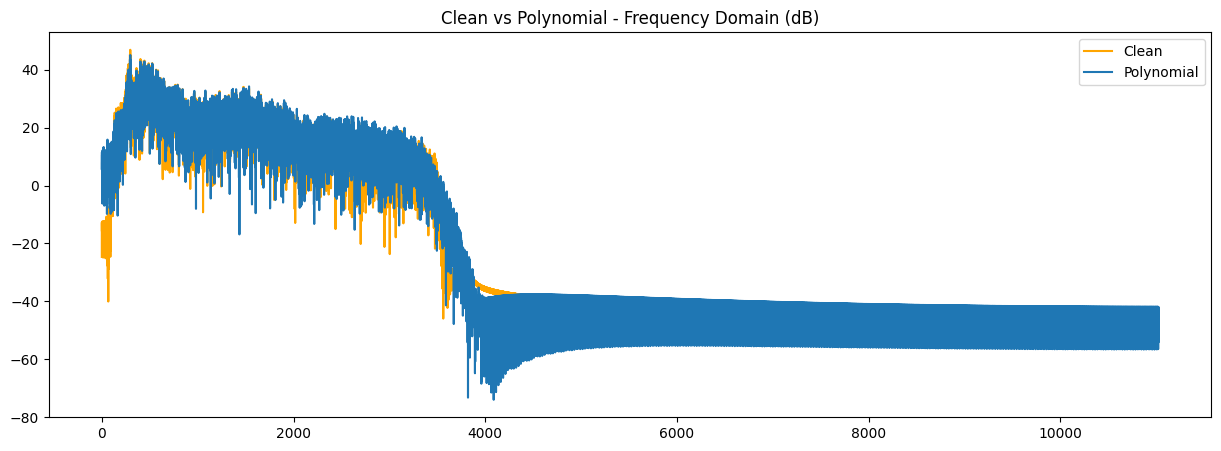

SNR for Cosine: 15.50 dB


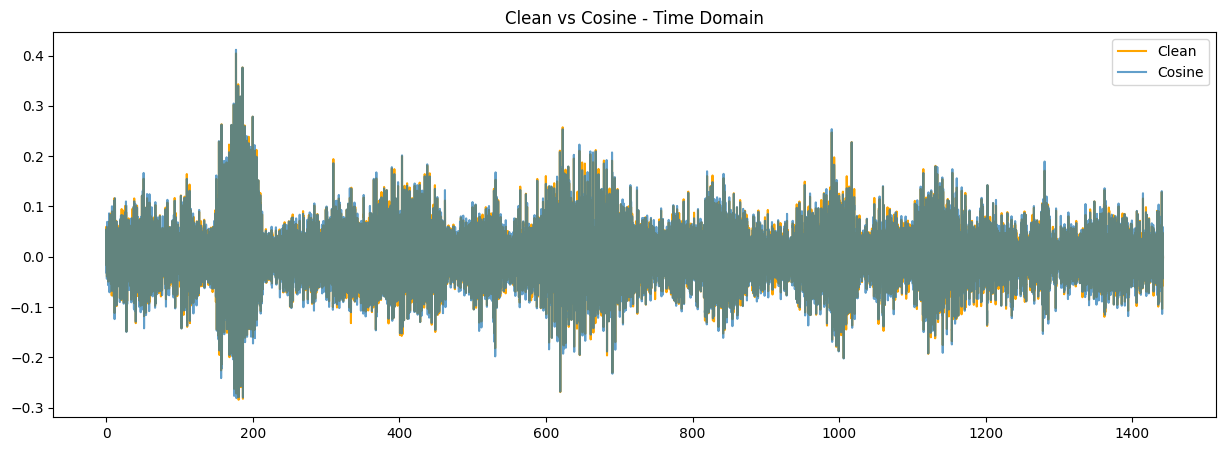

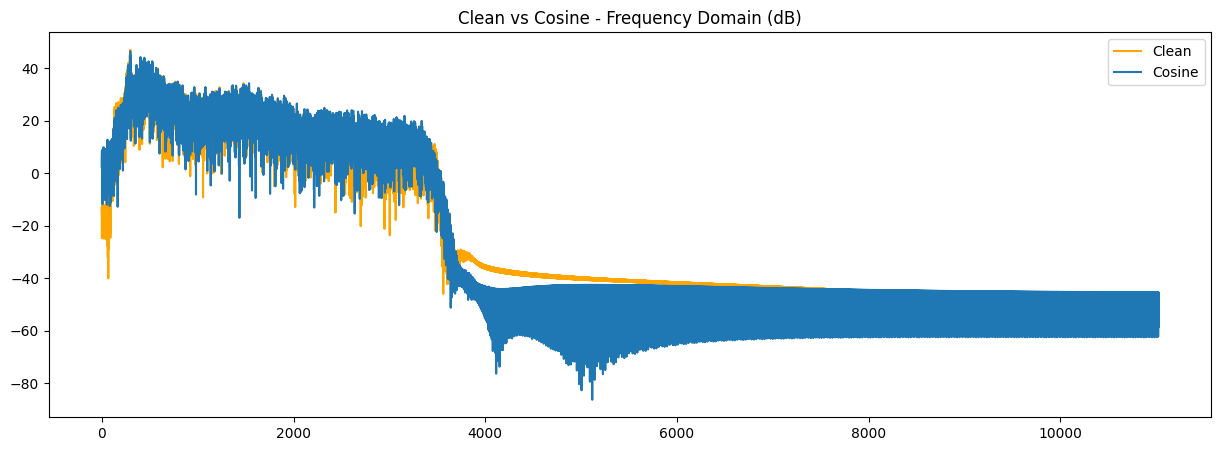

SNR for Hanning: 15.09 dB


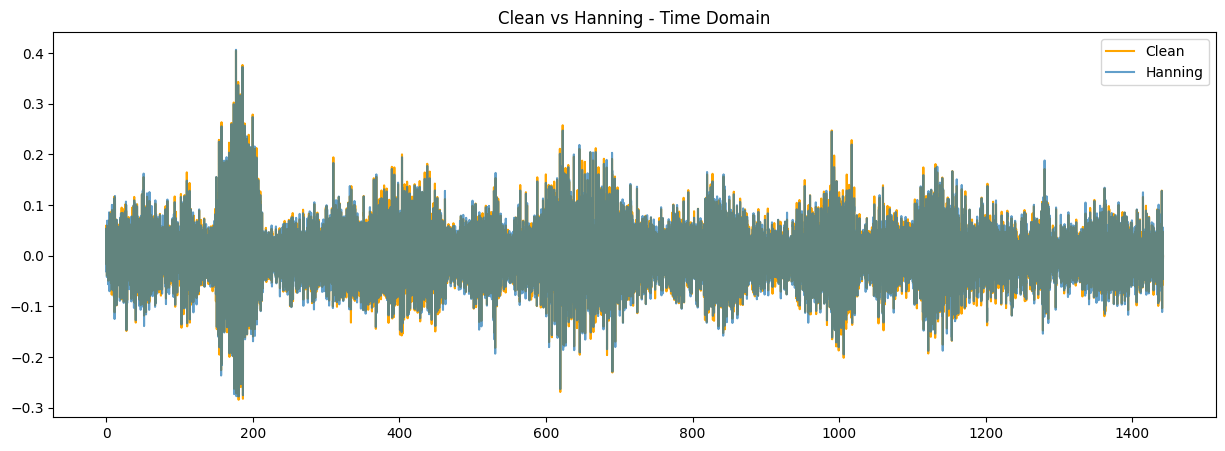

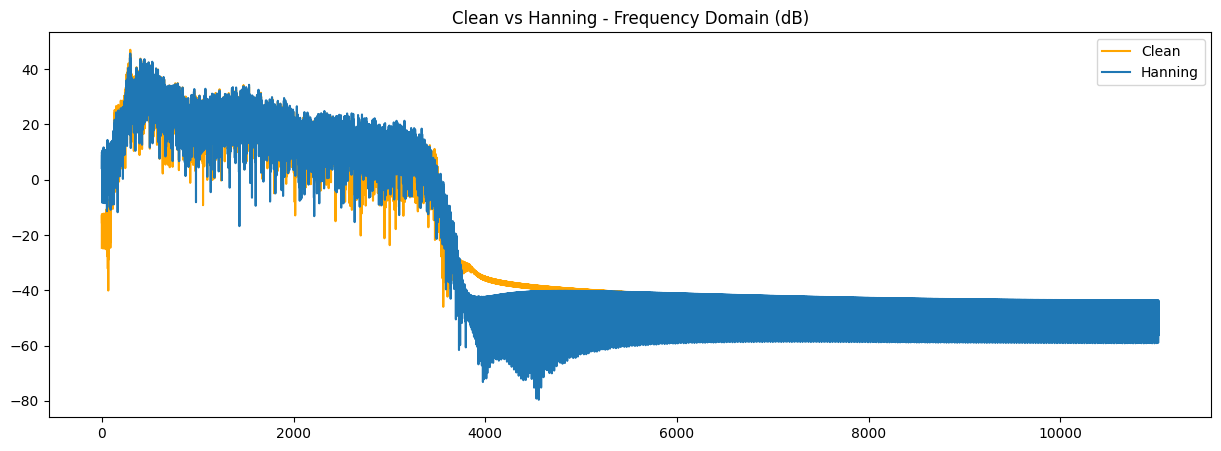

SNR for Hamming: 15.31 dB


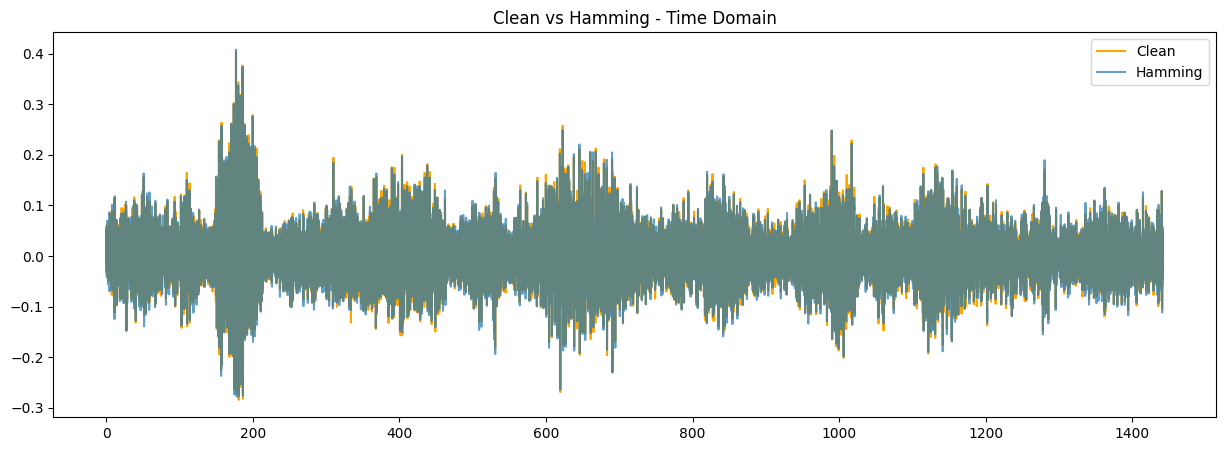

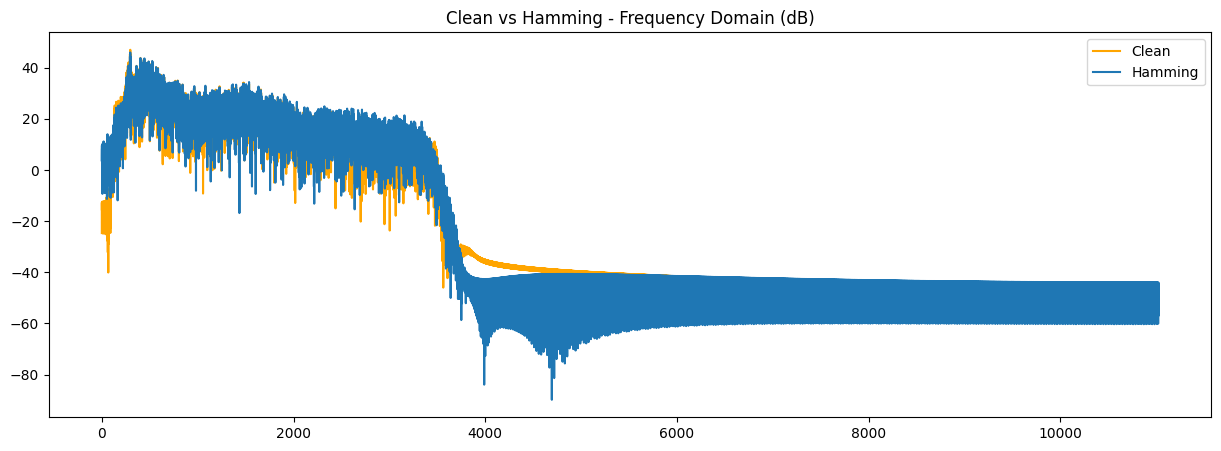

SNR for Blackman: 14.79 dB


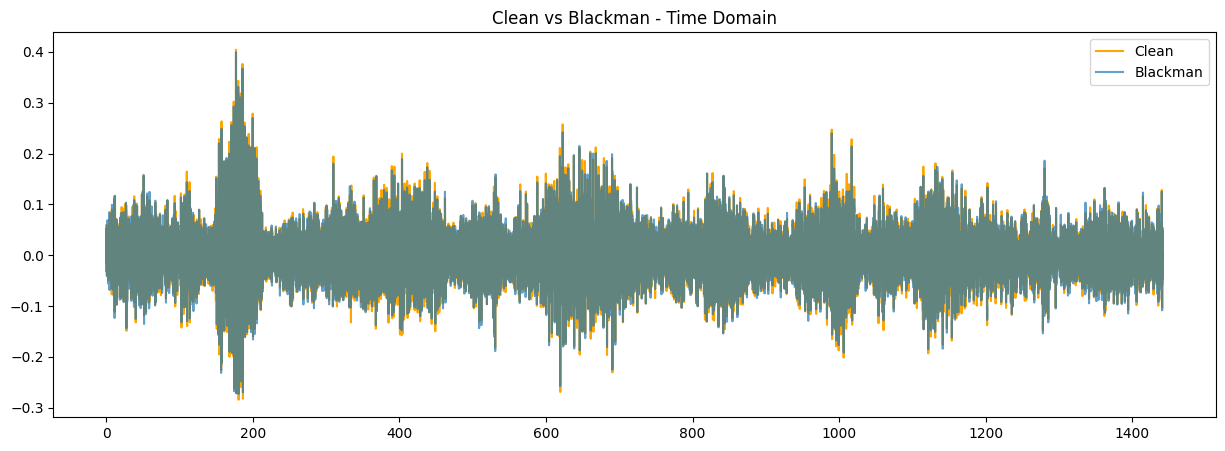

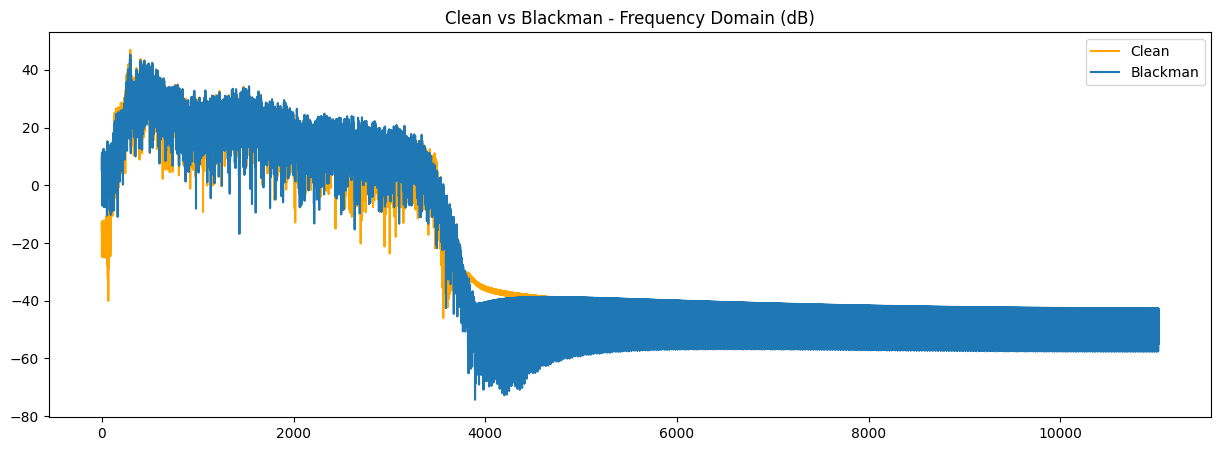

SNR for Kaiser: 15.58 dB


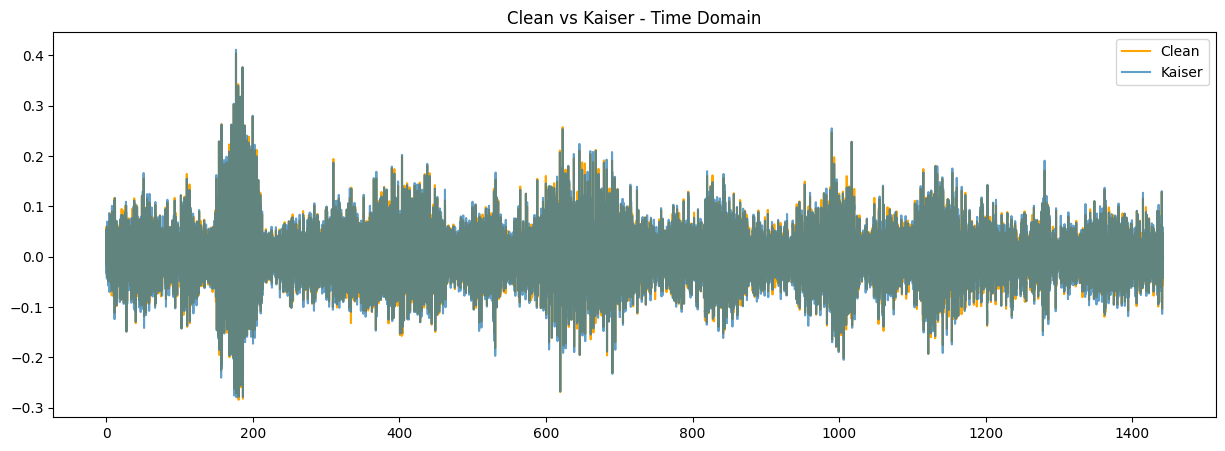

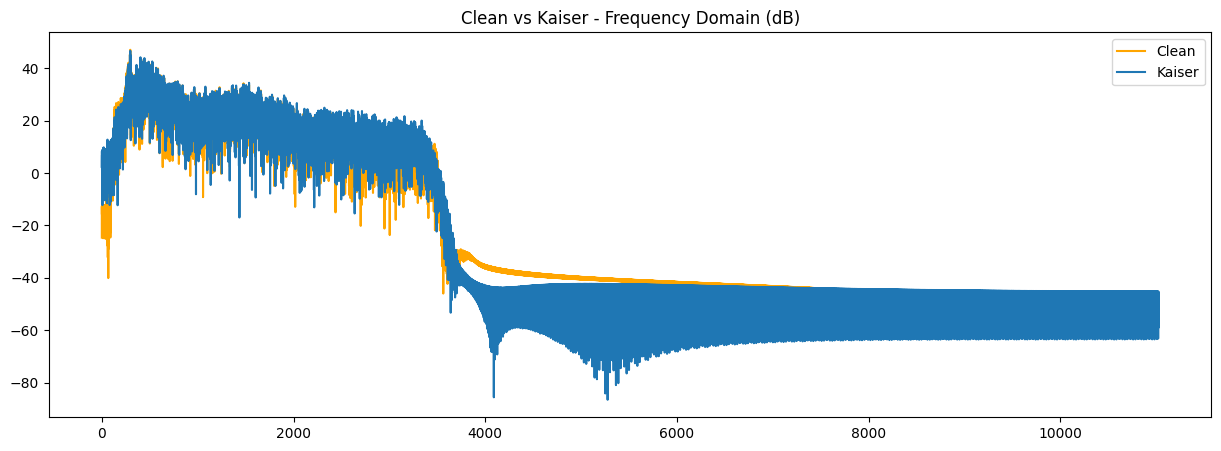

In [22]:
# Spécifications du filtre RIF
fnyquist = sr / 2
fc_b = 60
fc_h = 3490
freq_range = np.array([fc_b,fc_h])

width = 300 / fnyquist
ripple_dB = 40
N, beta = signal.kaiserord(ripple_dB, width) # pour la fenetre kaiser
t = librosa.frames_to_time(range(len(noisy_signal)), sr=sr)


# Liste des fenêtres
window_names = {
    "Rectangulare": "boxcar",
    "Triangulaire": "bartlett",
    "Parabolic": "parzen",
    "Polynomial": "blackmanharris",
    "Cosine": "cosine",
    "Hanning": "hann",
    "Hamming": "hamming",
    "Blackman": "blackman",
    "Kaiser": ("kaiser", beta)
}

filtered_signals = {}

# Appliquer chaque fenêtre
for name, window in window_names.items():
    filt = signal.firwin(
        101, cutoff=freq_range, pass_zero=False, window=window, fs=sr
    )
    filtered_audio = signal.filtfilt(filt, 1, noisy_signal)
    filtered_signals[name] = filtered_audio

    # Calcul SNR
    signal_power = np.mean(clean_audio ** 2)
    noise_power = np.mean((clean_audio - filtered_audio) ** 2)
    snr = 10 * np.log10(signal_power / noise_power)
    print(f"SNR for {name}: {snr:.2f} dB")

    # Sauvegarde du fichier audio filtré
    sf.write(f"{name}_audio.wav", filtered_audio, sr)

    # Affichage du signal dans le domaine temporel
    plt.figure(figsize=(15, 5))
    plt.plot(t, clean_audio, label="Clean", color="orange")
    plt.plot(t, filtered_audio, alpha=0.7, label=f"{name}")
    plt.title(f"Clean vs {name} - Time Domain")
    plt.legend()
    plt.show()

    # Affichage du signal dans le domaine fréquentiel
    w, h_clean = signal.freqz(clean_audio, worN=sr)
    w, h_filt = signal.freqz(filtered_audio, worN=sr)

    plt.figure(figsize=(15, 5))
    plt.plot(sr * w / (2 * np.pi), 20 * np.log10(np.abs(h_clean)), 'orange', label="Clean")
    plt.plot(sr * w / (2 * np.pi), 20 * np.log10(np.abs(h_filt)), label=f"{name}")
    plt.title(f"Clean vs {name} - Frequency Domain (dB)")
    plt.legend()
    plt.show()




L'analyse du SNR et du spectre des fréquences montre que la fenêtre triangulaire offre de meilleures performances en termes de filtrage spectral, tandis que la fenêtre rectangulaire est la moins efficace.
Maintenant passer a la filltre RII.

SNR for cheby1: 6.64 dB


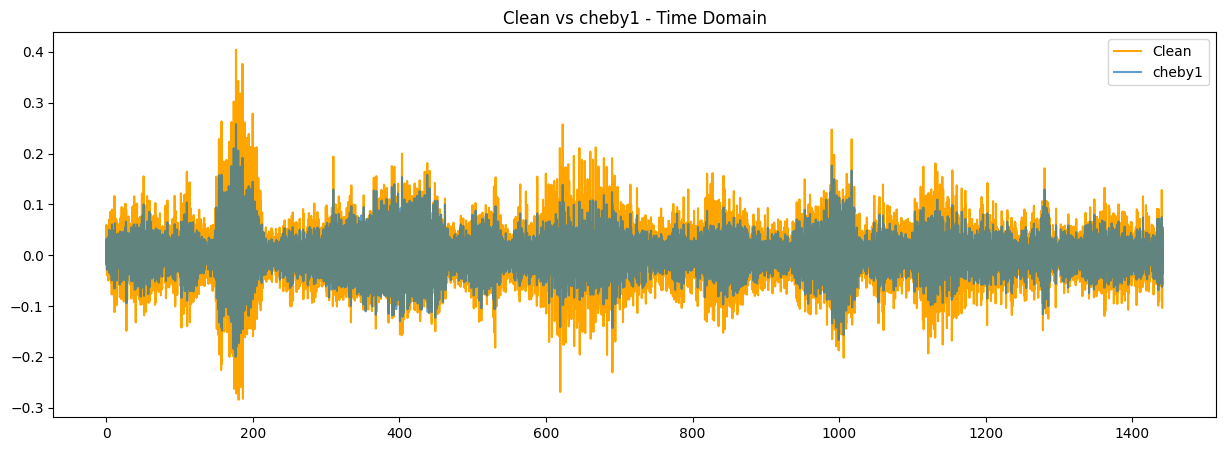

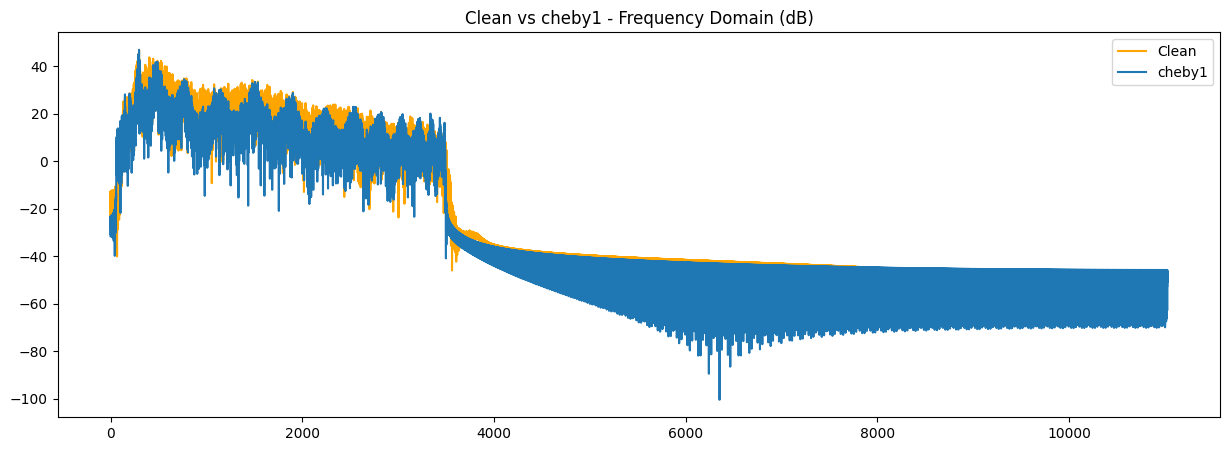

SNR for cauer: 5.41 dB


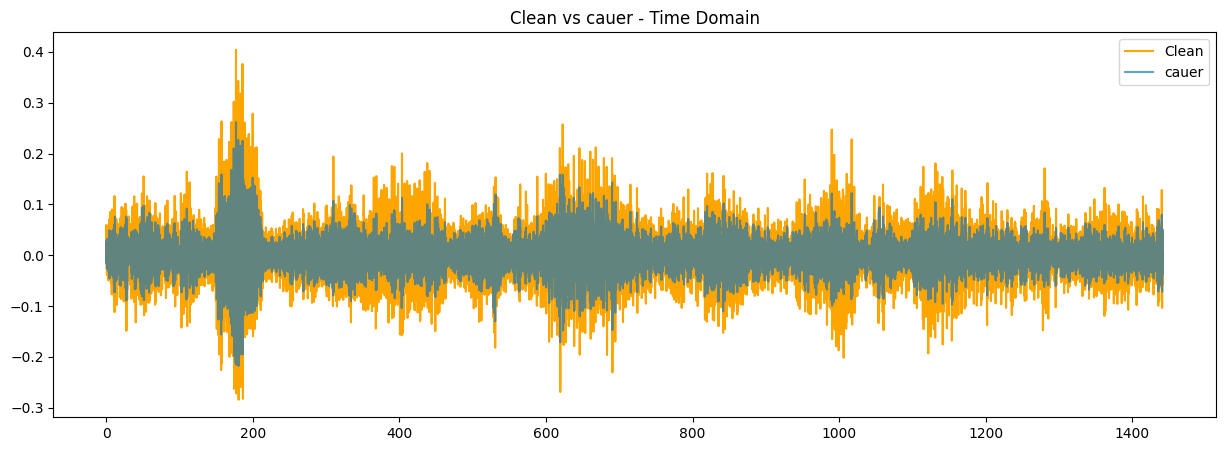

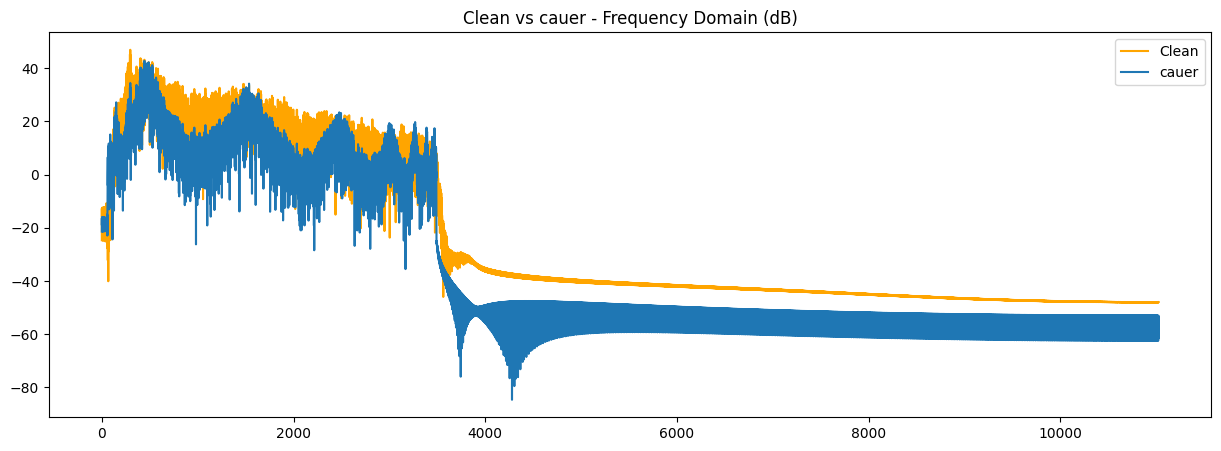

SNR for butter: 15.64 dB


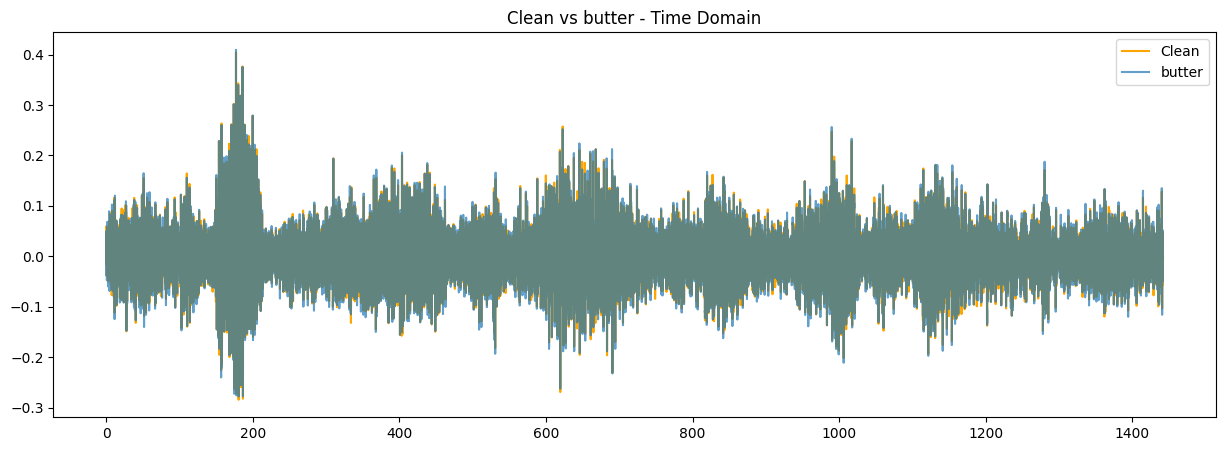

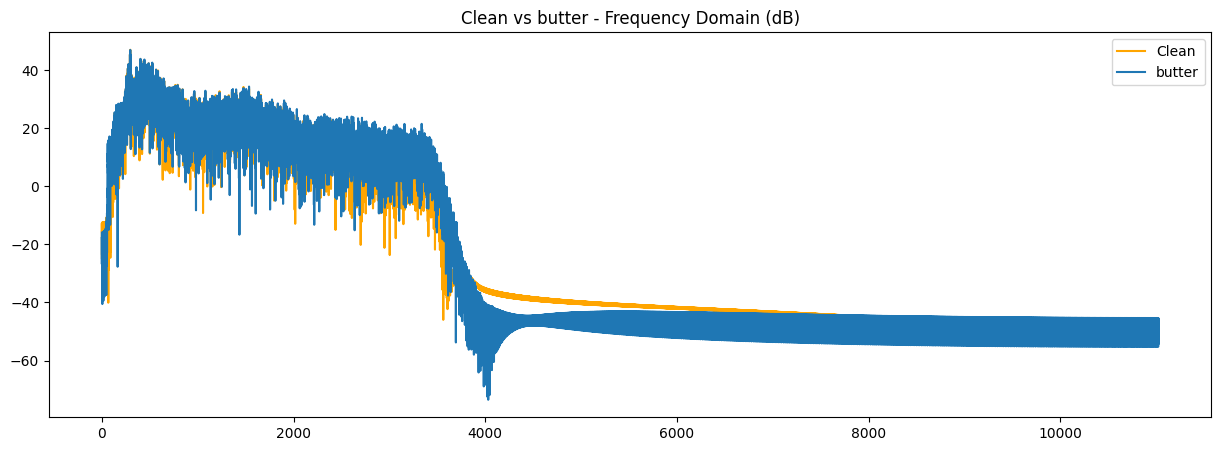

SNR for cheby2: 15.33 dB


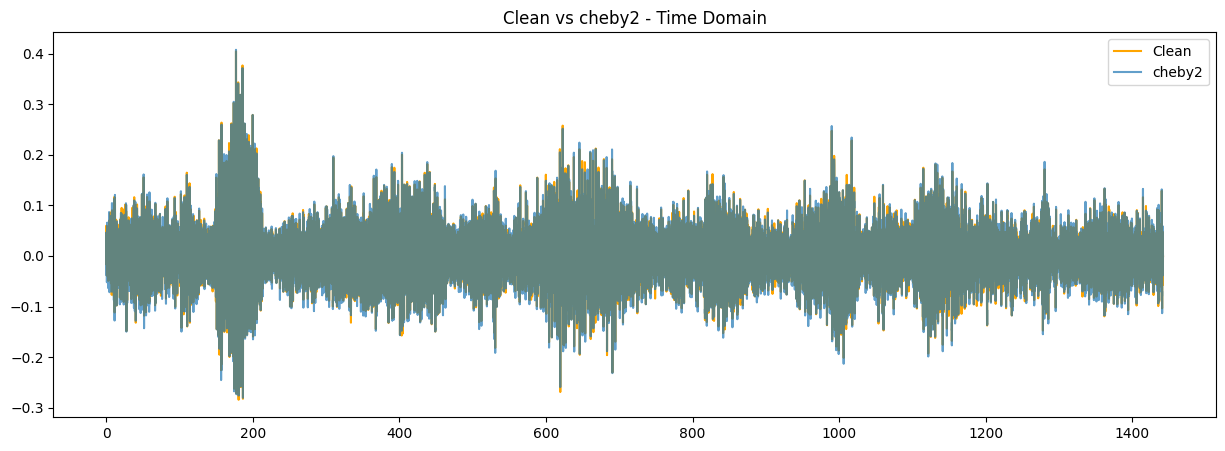

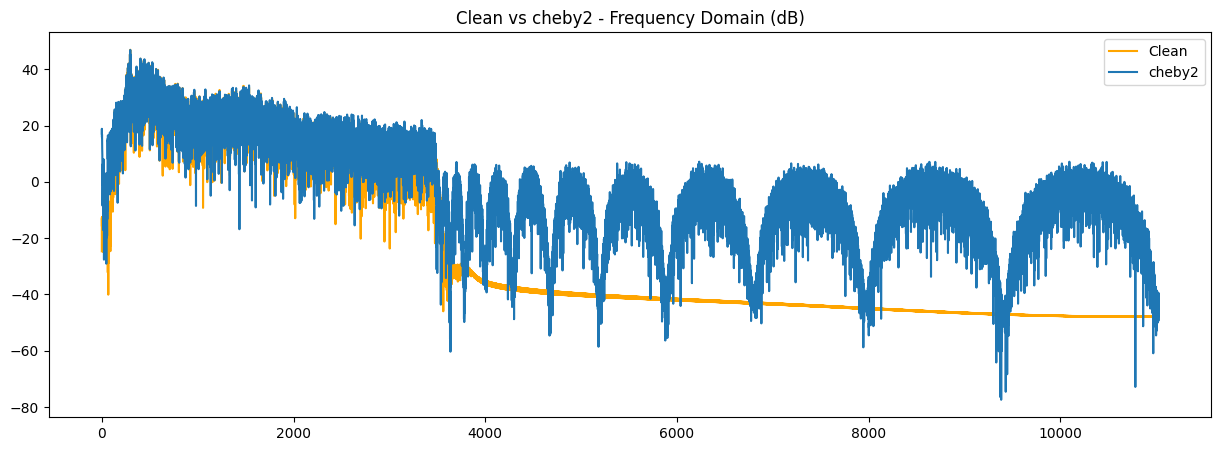

In [31]:
rii_filters={'cauer','cheby1','cheby2','butter'}
rii ={}
for name in rii_filters:
    filt = signal.iirfilter(25, freq_range / fnyquist, ftype=name, output='sos', rp=5, rs=6)

    filtered_audio = signal.sosfiltfilt(filt, noisy_signal)
    filtered_signals[name] = filtered_audio

    # Calcul SNR
    signal_power = np.mean(clean_audio ** 2)
    noise_power = np.mean((clean_audio - filtered_audio) ** 2)
    snr = 10 * np.log10(signal_power / noise_power)
    print(f"SNR for {name}: {snr:.2f} dB")

    # Sauvegarde du fichier audio filtré
    sf.write(f"{name}_audio.wav", filtered_audio, sr)

    # Affichage du signal dans le domaine temporel
    plt.figure(figsize=(15, 5))
    plt.plot(t, clean_audio, label="Clean", color="orange")
    plt.plot(t, filtered_audio, alpha=0.7, label=f"{name}")
    plt.title(f"Clean vs {name} - Time Domain")
    plt.legend()
    plt.show()

    # Affichage du signal dans le domaine fréquentiel
    w, h_clean = signal.freqz(clean_audio, worN=sr)
    w, h_filt = signal.freqz(filtered_audio, worN=sr)

    plt.figure(figsize=(15, 5))
    plt.plot(sr * w / (2 * np.pi), 20 * np.log10(np.abs(h_clean)), 'orange', label="Clean")
    plt.plot(sr * w / (2 * np.pi), 20 * np.log10(np.abs(h_filt)), label=f"{name}")
    plt.title(f"Clean vs {name} - Frequency Domain (dB)")
    plt.legend()
    plt.show()




*   Le filtre de Couer a donné une coupe plus nette
* Le filtre Cheby1 donnait une coupure plus nette que Butterworth mais plus douce que Couer, ce qui correspond à ce qu'avait le signal original (approximativement)
*Le filtre Cheby2 est similaire au filtre cheby1



  

